# 第2章: 確率分布と母関数

## 学習目標
- 確率分布の基本概念を理解する
- 確率質量関数と確率密度関数を区別できる
- 母関数（積率母関数、確率母関数、特性関数）の定義と性質を理解する
- 母関数を用いた計算ができるようになる

# 第2章: 確率分布と母関数

## 📋 学習メタ情報

### 学習目標
- ☑ 確率分布の基本概念（PMF、PDF、CDF）を理解する
- ☑ 積率母関数（MGF）の定義と性質を習得する
- ☑ 確率母関数（PGF）を使いこなせるようになる
- ☑ 特性関数の理論的重要性を理解する
- ☑ 母関数を用いた確率変数の和の計算ができる
- ☑ キュムラント母関数の応用を学ぶ

### 前提知識
- 第1章の内容（確率の基礎、条件付き確率）
- 微分積分学（テイラー展開、ラプラス変換の基礎）
- 複素数の基礎知識（特性関数で使用）
- Python基礎（NumPy、SciPy、Sympyの基本操作）

### 推定学習時間
**120〜150分**（コード実行、シミュレーション、練習問題を含む）

### 難易度
**★★★☆☆** (5段階中3)

### カテゴリー
**確率論の数理的基礎** - 統計検定準1級の理論的中核

---

## 🎯 なぜこの章を学ぶのか？

### この章の重要性

母関数は確率論における**最も強力な道具の一つ**です。複雑な確率計算を代数的な操作に変換することで、直接計算が困難な問題を優雅に解決できます。

**なぜ母関数が重要なのか：**

1. **計算の簡略化**: 確率変数の和の分布を求める際、畳み込み積分の代わりに単純な掛け算で済む
2. **分布の特定**: MGFや特性関数は分布を一意に決定するため、2つの確率変数が同じ分布に従うことを証明できる
3. **積率の計算**: 期待値、分散、歪度、尖度などを系統的に計算できる
4. **極限定理への応用**: 中心極限定理などの証明に不可欠
5. **理論と実践の架け橋**: 抽象的な確率論を具体的な計算に落とし込む

### 実世界での応用

**例1: 通信ネットワークの設計**
複数のデータパケットが同時に到着する確率を計算する際、各パケットの到着がポアソン過程に従う場合、母関数を使って合成過程の分布を導出します。これにより、必要なバッファサイズやネットワーク容量を数学的に設計できます。

**例2: 金融工学におけるリスク計算**
複数の独立な投資商品のポートフォリオ全体のリスク（分散）を計算する際、MGFを使うことで各商品の分散を加算するだけで全体の分散が求まります。これは「リスクの加法性」として実務で広く使われています。

**例3: 機械学習の理論解析**
ニューラルネットワークの勾配降下法において、ミニバッチごとの勾配推定値の分布を解析する際、MGFを使って収束速度や必要なバッチサイズを理論的に導出します。

**例4: 品質管理**
製造ラインで複数の工程がある場合、各工程での不良品発生確率から最終製品の不良率を計算する際、PGFを使うことで複雑な確率計算が簡潔になります。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import factorial
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

# =============================================================================
# 離散型確率分布と連続型確率分布の視覚的比較
# =============================================================================
# 【目的】PMF/CDFとPDF/CDFの違いを直感的に理解する
# 【比喩】離散型は「階段」、連続型は「滑らかな曲線」

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------------------------------------------------------
# 離散型の例: ポアソン分布 Poi(λ=5)
# -----------------------------------------------------------------------------
# ポアソン分布: 単位時間あたりの事象発生回数をモデル化
# 例: 1時間あたりのウェブサイト訪問者数、1日あたりのメール受信数

lam = 5  # λ=5: 平均5回の事象が発生
x_discrete = np.arange(0, 15)  # 取りうる値: 0, 1, 2, ..., 14

# PMF (確率質量関数): 各値を取る確率
# P(X = k) = (λ^k * e^(-λ)) / k!
pmf = stats.poisson.pmf(x_discrete, lam)

# CDF (累積分布関数): X ≤ k となる確率
# F(k) = P(X ≤ k) = Σ(i=0 to k) P(X = i)
cdf_discrete = stats.poisson.cdf(x_discrete, lam)

# PMFの可視化: 棒グラフで表現（離散的な値のため）
axes[0, 0].bar(x_discrete, pmf, color='steelblue', alpha=0.7)
axes[0, 0].set_title(f'PMF: Poisson(λ={lam})', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('x （発生回数）')
axes[0, 0].set_ylabel('P(X = x) （確率）')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

# CDFの可視化: 階段関数で表現（離散型の特徴）
# where='mid': 階段の中央で値が変化するように描画
axes[0, 1].step(x_discrete, cdf_discrete, where='mid', color='steelblue', linewidth=2)
axes[0, 1].scatter(x_discrete, cdf_discrete, color='steelblue', s=50, zorder=5)
axes[0, 1].set_title(f'CDF: Poisson(λ={lam})', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('P(X ≤ x) （累積確率）')
axes[0, 1].grid(True, alpha=0.3, linestyle='--')

# -----------------------------------------------------------------------------
# 連続型の例: 正規分布 N(μ=5, σ=1.5)
# -----------------------------------------------------------------------------
# 正規分布: 自然界や測定誤差で最も頻繁に現れる分布
# 例: 身長、試験の点数、製品の寸法誤差

mu, sigma = 5, 1.5  # μ=5（平均）, σ=1.5（標準偏差）
x_continuous = np.linspace(0, 10, 200)  # 0から10まで200点で密に評価

# PDF (確率密度関数): 密度を表す（確率ではない！）
# f(x) = (1/√(2πσ²)) * exp(-(x-μ)²/(2σ²))
# 注意: f(x)自体は確率ではなく、積分すると確率になる
pdf = stats.norm.pdf(x_continuous, mu, sigma)

# CDF (累積分布関数): X ≤ x となる確率
# F(x) = P(X ≤ x) = ∫(-∞ to x) f(t)dt
cdf_continuous = stats.norm.cdf(x_continuous, mu, sigma)

# PDFの可視化: 滑らかな曲線で表現
# fill_between: 曲線下の面積が確率を表すことを視覚化
axes[1, 0].plot(x_continuous, pdf, color='coral', linewidth=2)
axes[1, 0].fill_between(x_continuous, pdf, alpha=0.3, color='coral')
axes[1, 0].set_title(f'PDF: Normal(μ={mu}, σ={sigma})', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('f(x) （密度）')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')

# CDFの可視化: 滑らかなS字カーブ（連続型の特徴）
# 離散型のCDFとは異なり、飛びがない
axes[1, 1].plot(x_continuous, cdf_continuous, color='coral', linewidth=2)
axes[1, 1].set_title(f'CDF: Normal(μ={mu}, σ={sigma})', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('F(x) = P(X ≤ x)')
axes[1, 1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# 重要な観察ポイント:
# 1. 離散型のCDFは「階段状」、連続型のCDFは「滑らか」
# 2. PMFは確率そのもの、PDFは密度（積分して初めて確率）
# 3. どちらのCDFも単調増加で、lim(x→∞) F(x) = 1

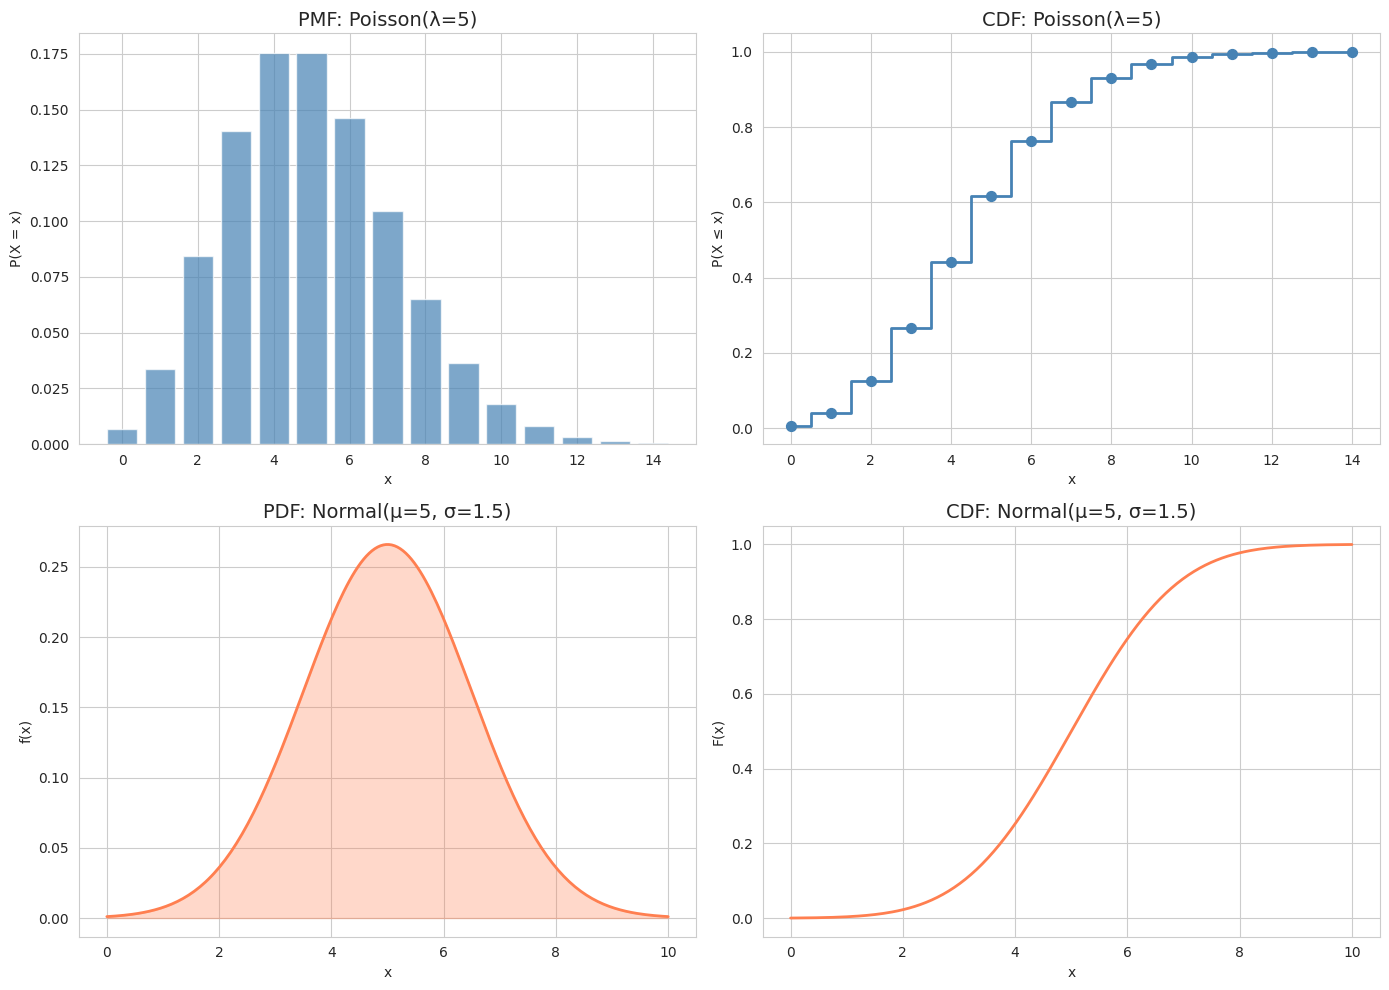

In [2]:
# 離散型と連続型の比較
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 離散型: ポアソン分布
lam = 5
x_discrete = np.arange(0, 15)
pmf = stats.poisson.pmf(x_discrete, lam)
cdf_discrete = stats.poisson.cdf(x_discrete, lam)

axes[0, 0].bar(x_discrete, pmf, color='steelblue', alpha=0.7)
axes[0, 0].set_title(f'PMF: Poisson(λ={lam})', fontsize=14)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('P(X = x)')

axes[0, 1].step(x_discrete, cdf_discrete, where='mid', color='steelblue', linewidth=2)
axes[0, 1].scatter(x_discrete, cdf_discrete, color='steelblue', s=50, zorder=5)
axes[0, 1].set_title(f'CDF: Poisson(λ={lam})', fontsize=14)
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('P(X ≤ x)')

# 連続型: 正規分布
mu, sigma = 5, 1.5
x_continuous = np.linspace(0, 10, 200)
pdf = stats.norm.pdf(x_continuous, mu, sigma)
cdf_continuous = stats.norm.cdf(x_continuous, mu, sigma)

axes[1, 0].plot(x_continuous, pdf, color='coral', linewidth=2)
axes[1, 0].fill_between(x_continuous, pdf, alpha=0.3, color='coral')
axes[1, 0].set_title(f'PDF: Normal(μ={mu}, σ={sigma})', fontsize=14)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('f(x)')

axes[1, 1].plot(x_continuous, cdf_continuous, color='coral', linewidth=2)
axes[1, 1].set_title(f'CDF: Normal(μ={mu}, σ={sigma})', fontsize=14)
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('F(x)')

plt.tight_layout()
plt.show()

## 2.2 積率母関数 (Moment Generating Function)

### 定義
$$M_X(t) = E[e^{tX}]$$

- 離散型: $M_X(t) = \sum_x e^{tx} p(x)$
- 連続型: $M_X(t) = \int_{-\infty}^{\infty} e^{tx} f(x) dx$

### 重要な性質
1. **積率の計算**: $E[X^n] = M_X^{(n)}(0) = \frac{d^n}{dt^n} M_X(t) \big|_{t=0}$
2. **一意性**: MGFが存在すれば、分布を一意に決定
3. **独立変数の和**: $X, Y$が独立なら $M_{X+Y}(t) = M_X(t) \cdot M_Y(t)$
4. **線形変換**: $M_{aX+b}(t) = e^{bt} M_X(at)$

In [3]:
# 主要分布のMGF
print("主要な分布の積率母関数")
print("="*60)
print("\n1. ベルヌーイ分布 Ber(p):")
print("   M_X(t) = 1 - p + p*e^t")
print("\n2. 二項分布 Bin(n, p):")
print("   M_X(t) = (1 - p + p*e^t)^n")
print("\n3. ポアソン分布 Poi(λ):")
print("   M_X(t) = exp(λ(e^t - 1))")
print("\n4. 指数分布 Exp(λ):")
print("   M_X(t) = λ/(λ - t), t < λ")
print("\n5. 正規分布 N(μ, σ²):")
print("   M_X(t) = exp(μt + σ²t²/2)")
print("\n6. ガンマ分布 Gamma(α, β):")
print("   M_X(t) = (1 - t/β)^(-α), t < β")

主要な分布の積率母関数

1. ベルヌーイ分布 Ber(p):
   M_X(t) = 1 - p + p*e^t

2. 二項分布 Bin(n, p):
   M_X(t) = (1 - p + p*e^t)^n

3. ポアソン分布 Poi(λ):
   M_X(t) = exp(λ(e^t - 1))

4. 指数分布 Exp(λ):
   M_X(t) = λ/(λ - t), t < λ

5. 正規分布 N(μ, σ²):
   M_X(t) = exp(μt + σ²t²/2)

6. ガンマ分布 Gamma(α, β):
   M_X(t) = (1 - t/β)^(-α), t < β


In [4]:
# MGFから積率を計算する例：正規分布
import sympy as sp

t, mu, sigma = sp.symbols('t mu sigma', real=True)
sigma = sp.symbols('sigma', positive=True)

# 正規分布のMGF
M = sp.exp(mu*t + sigma**2 * t**2 / 2)

# 1次微分（期待値）
M_prime = sp.diff(M, t)
E_X = M_prime.subs(t, 0)

# 2次微分
M_double_prime = sp.diff(M, t, 2)
E_X2 = M_double_prime.subs(t, 0)

print("正規分布 N(μ, σ²) のMGFから積率を計算")
print("="*50)
print(f"M_X(t) = {M}")
print(f"\nM'_X(t) = {M_prime}")
print(f"E[X] = M'_X(0) = {E_X}")
print(f"\nM''_X(t) = {sp.simplify(M_double_prime)}")
print(f"E[X²] = M''_X(0) = {E_X2}")
print(f"\nVar(X) = E[X²] - E[X]² = {sp.simplify(E_X2 - E_X**2)}")

正規分布 N(μ, σ²) のMGFから積率を計算
M_X(t) = exp(mu*t + sigma**2*t**2/2)

M'_X(t) = (mu + sigma**2*t)*exp(mu*t + sigma**2*t**2/2)
E[X] = M'_X(0) = mu

M''_X(t) = (sigma**2 + (mu + sigma**2*t)**2)*exp(t*(2*mu + sigma**2*t)/2)
E[X²] = M''_X(0) = mu**2 + sigma**2

Var(X) = E[X²] - E[X]² = sigma**2


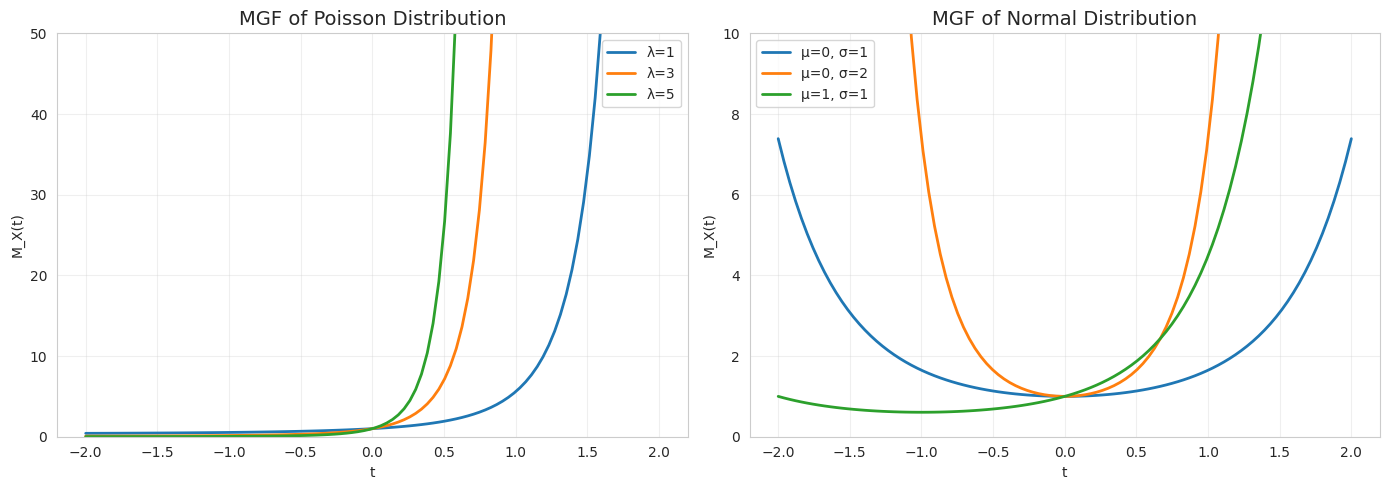

In [5]:
# MGFの可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t_vals = np.linspace(-2, 2, 100)

# ポアソン分布のMGF
for lam in [1, 3, 5]:
    mgf_poisson = np.exp(lam * (np.exp(t_vals) - 1))
    axes[0].plot(t_vals, mgf_poisson, label=f'λ={lam}', linewidth=2)
axes[0].set_title('MGF of Poisson Distribution', fontsize=14)
axes[0].set_xlabel('t')
axes[0].set_ylabel('M_X(t)')
axes[0].legend()
axes[0].set_ylim([0, 50])
axes[0].grid(True, alpha=0.3)

# 正規分布のMGF
for mu, sigma in [(0, 1), (0, 2), (1, 1)]:
    mgf_normal = np.exp(mu * t_vals + sigma**2 * t_vals**2 / 2)
    axes[1].plot(t_vals, mgf_normal, label=f'μ={mu}, σ={sigma}', linewidth=2)
axes[1].set_title('MGF of Normal Distribution', fontsize=14)
axes[1].set_xlabel('t')
axes[1].set_ylabel('M_X(t)')
axes[1].legend()
axes[1].set_ylim([0, 10])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3 確率母関数 (Probability Generating Function)

### 定義（非負整数値の確率変数）
$$G_X(s) = E[s^X] = \sum_{k=0}^{\infty} s^k P(X = k)$$

### 重要な性質
1. **確率の復元**: $P(X = k) = \frac{G_X^{(k)}(0)}{k!}$
2. **期待値**: $E[X] = G_X'(1)$
3. **分散**: $Var(X) = G_X''(1) + G_X'(1) - [G_X'(1)]^2$
4. **独立変数の和**: $G_{X+Y}(s) = G_X(s) \cdot G_Y(s)$

In [6]:
# 確率母関数の例
print("主要な離散分布の確率母関数")
print("="*60)
print("\n1. ベルヌーイ分布 Ber(p):")
print("   G_X(s) = 1 - p + ps")
print("\n2. 二項分布 Bin(n, p):")
print("   G_X(s) = (1 - p + ps)^n")
print("\n3. ポアソン分布 Poi(λ):")
print("   G_X(s) = exp(λ(s - 1))")
print("\n4. 幾何分布 Geo(p):")
print("   G_X(s) = ps/(1 - (1-p)s)")
print("\n5. 負の二項分布 NB(r, p):")
print("   G_X(s) = (ps/(1 - (1-p)s))^r")

主要な離散分布の確率母関数

1. ベルヌーイ分布 Ber(p):
   G_X(s) = 1 - p + ps

2. 二項分布 Bin(n, p):
   G_X(s) = (1 - p + ps)^n

3. ポアソン分布 Poi(λ):
   G_X(s) = exp(λ(s - 1))

4. 幾何分布 Geo(p):
   G_X(s) = ps/(1 - (1-p)s)

5. 負の二項分布 NB(r, p):
   G_X(s) = (ps/(1 - (1-p)s))^r


In [7]:
# PGFから期待値と分散を計算：ポアソン分布
s, lam_sym = sp.symbols('s lambda', positive=True)

# ポアソン分布のPGF
G = sp.exp(lam_sym * (s - 1))

G_prime = sp.diff(G, s)
G_double_prime = sp.diff(G, s, 2)

E_X = G_prime.subs(s, 1)
Var_X = G_double_prime.subs(s, 1) + G_prime.subs(s, 1) - G_prime.subs(s, 1)**2

print("ポアソン分布 Poi(λ) のPGFから統計量を計算")
print("="*50)
print(f"G_X(s) = {G}")
print(f"G'_X(s) = {G_prime}")
print(f"\nE[X] = G'_X(1) = {E_X}")
print(f"Var(X) = {sp.simplify(Var_X)}")

ポアソン分布 Poi(λ) のPGFから統計量を計算
G_X(s) = exp(lambda*(s - 1))
G'_X(s) = lambda*exp(lambda*(s - 1))

E[X] = G'_X(1) = lambda
Var(X) = lambda


## 2.4 特性関数 (Characteristic Function)

### 定義
$$\phi_X(t) = E[e^{itX}]$$

ここで $i$ は虚数単位。

### 重要な性質
1. **常に存在**: 全ての確率変数に対して定義可能
2. **有界**: $|\phi_X(t)| \leq 1$
3. **積率**: $E[X^n] = \frac{1}{i^n} \phi_X^{(n)}(0)$
4. **一意性**: 特性関数は分布を一意に決定
5. **反転公式が存在**

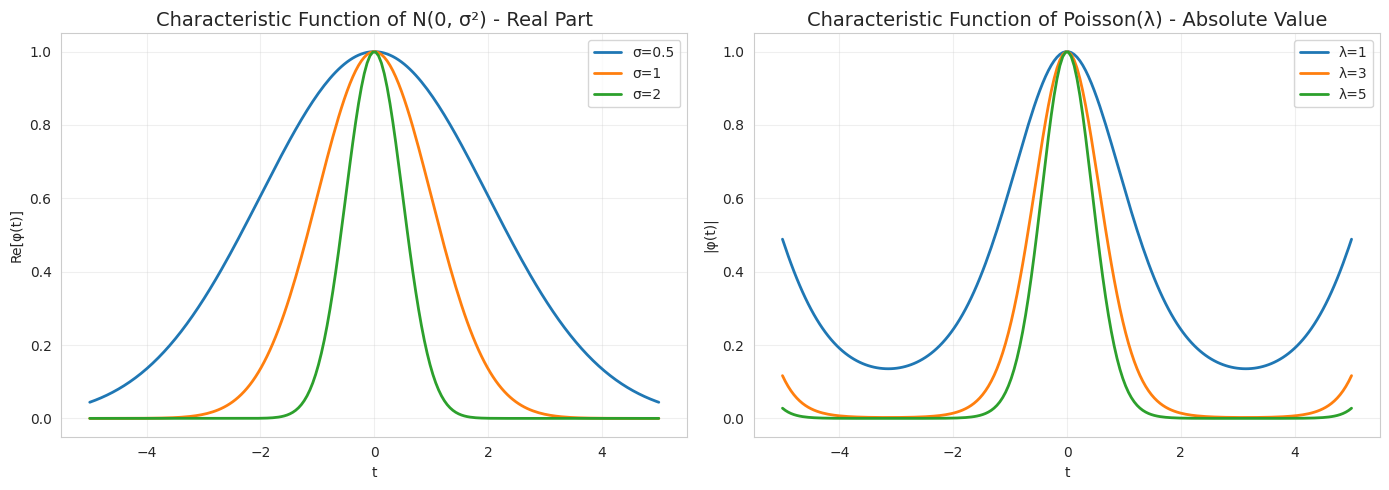

In [8]:
# 特性関数の可視化：正規分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t_vals = np.linspace(-5, 5, 200)

# 正規分布 N(0, σ²) の特性関数: exp(-σ²t²/2)
for sigma in [0.5, 1, 2]:
    cf_real = np.exp(-sigma**2 * t_vals**2 / 2)  # 実部（虚部は0）
    axes[0].plot(t_vals, cf_real, label=f'σ={sigma}', linewidth=2)

axes[0].set_title('Characteristic Function of N(0, σ²) - Real Part', fontsize=14)
axes[0].set_xlabel('t')
axes[0].set_ylabel('Re[φ(t)]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ポアソン分布の特性関数: exp(λ(e^(it) - 1))
for lam in [1, 3, 5]:
    cf_complex = np.exp(lam * (np.exp(1j * t_vals) - 1))
    axes[1].plot(t_vals, np.abs(cf_complex), label=f'λ={lam}', linewidth=2)

axes[1].set_title('Characteristic Function of Poisson(λ) - Absolute Value', fontsize=14)
axes[1].set_xlabel('t')
axes[1].set_ylabel('|φ(t)|')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.5 母関数の応用：独立な確率変数の和

独立な確率変数の和の分布を求める際、母関数が非常に有用です。

### 定理
$X$ と $Y$ が独立なとき:
- $M_{X+Y}(t) = M_X(t) \cdot M_Y(t)$
- $G_{X+Y}(s) = G_X(s) \cdot G_Y(s)$
- $\phi_{X+Y}(t) = \phi_X(t) \cdot \phi_Y(t)$

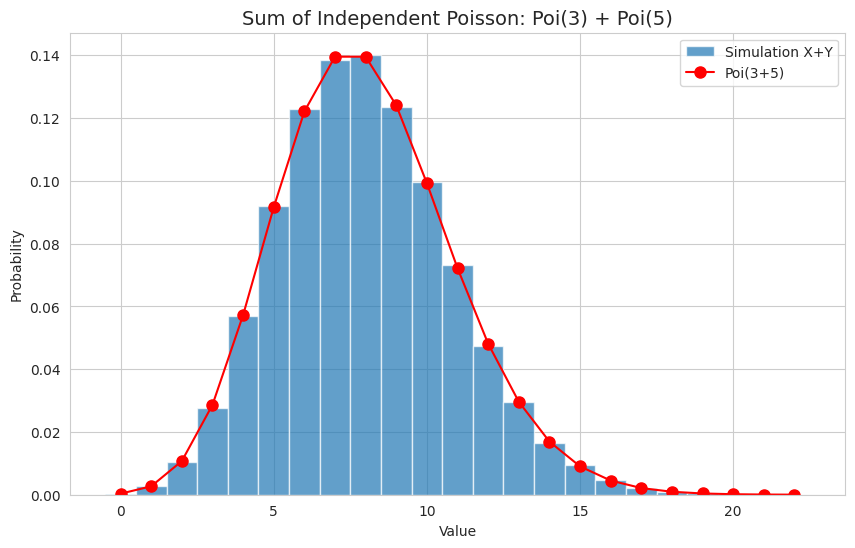

理論平均: 8, シミュレーション平均: 8.0141
理論分散: 8, シミュレーション分散: 8.0128


In [9]:
# 独立なポアソン変数の和がポアソンになることをシミュレーション
n_samples = 100000

lam1, lam2 = 3, 5
X = np.random.poisson(lam1, n_samples)
Y = np.random.poisson(lam2, n_samples)
Z = X + Y

# 理論的にはZ ~ Poi(λ1 + λ2)
fig, ax = plt.subplots(figsize=(10, 6))

# ヒストグラム
max_val = max(Z) + 1
bins = np.arange(-0.5, max_val + 0.5, 1)
ax.hist(Z, bins=bins, density=True, alpha=0.7, label='Simulation X+Y')

# 理論分布
x_vals = np.arange(0, max_val)
theoretical = stats.poisson.pmf(x_vals, lam1 + lam2)
ax.plot(x_vals, theoretical, 'ro-', markersize=8, label=f'Poi({lam1}+{lam2})')

ax.set_title(f'Sum of Independent Poisson: Poi({lam1}) + Poi({lam2})', fontsize=14)
ax.set_xlabel('Value')
ax.set_ylabel('Probability')
ax.legend()
plt.show()

print(f"理論平均: {lam1 + lam2}, シミュレーション平均: {np.mean(Z):.4f}")
print(f"理論分散: {lam1 + lam2}, シミュレーション分散: {np.var(Z):.4f}")

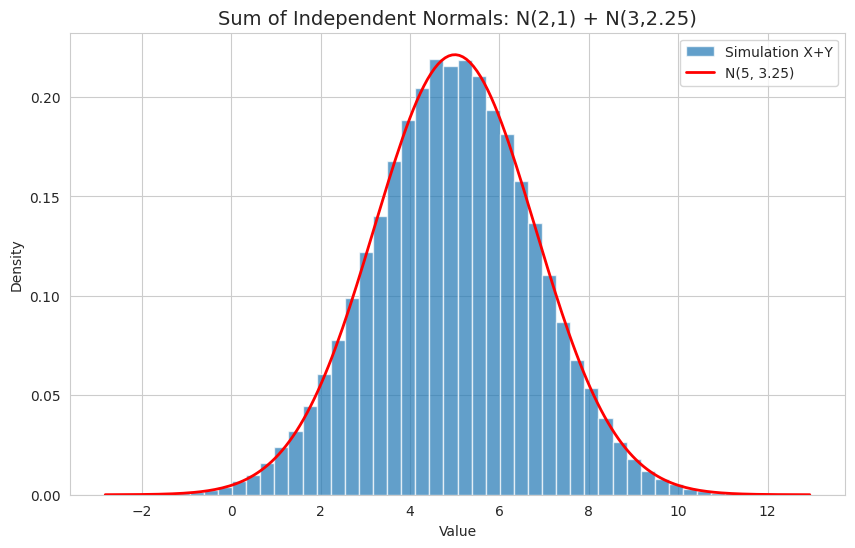

In [10]:
# 独立な正規変数の和
n_samples = 100000

mu1, sigma1 = 2, 1
mu2, sigma2 = 3, 1.5

X = np.random.normal(mu1, sigma1, n_samples)
Y = np.random.normal(mu2, sigma2, n_samples)
Z = X + Y

# 理論的には Z ~ N(μ1+μ2, σ1²+σ2²)
mu_sum = mu1 + mu2
sigma_sum = np.sqrt(sigma1**2 + sigma2**2)

fig, ax = plt.subplots(figsize=(10, 6))

# ヒストグラム
ax.hist(Z, bins=50, density=True, alpha=0.7, label='Simulation X+Y')

# 理論分布
x_vals = np.linspace(min(Z), max(Z), 200)
theoretical = stats.norm.pdf(x_vals, mu_sum, sigma_sum)
ax.plot(x_vals, theoretical, 'r-', linewidth=2, 
        label=f'N({mu_sum}, {sigma_sum**2:.2f})')

ax.set_title(f'Sum of Independent Normals: N({mu1},{sigma1**2}) + N({mu2},{sigma2**2})', 
             fontsize=14)
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
plt.show()

## 2.6 キュムラント母関数

### 定義
$$K_X(t) = \log M_X(t)$$

### キュムラント
$$\kappa_n = K_X^{(n)}(0)$$

- $\kappa_1 = E[X]$ (平均)
- $\kappa_2 = Var(X)$ (分散)
- $\kappa_3$ (歪度に関連)
- $\kappa_4$ (尖度に関連)

### 重要な性質
独立な確率変数の和のキュムラントは、各キュムラントの和:
$$K_{X+Y}(t) = K_X(t) + K_Y(t)$$

In [11]:
# キュムラントの計算例：正規分布
t_sym = sp.symbols('t')
mu_sym, sigma_sym = sp.symbols('mu sigma', real=True)

# 正規分布のMGF
M_normal = sp.exp(mu_sym * t_sym + sigma_sym**2 * t_sym**2 / 2)
K_normal = sp.log(M_normal)

print("正規分布のキュムラント母関数")
print("="*50)
print(f"K_X(t) = log(M_X(t)) = {K_normal}")
print(f"\nキュムラント:")
print(f"κ₁ = K'(0) = {sp.diff(K_normal, t_sym).subs(t_sym, 0)}")
print(f"κ₂ = K''(0) = {sp.diff(K_normal, t_sym, 2).subs(t_sym, 0)}")
print(f"κ₃ = K'''(0) = {sp.diff(K_normal, t_sym, 3).subs(t_sym, 0)}")
print(f"κ₄ = K''''(0) = {sp.diff(K_normal, t_sym, 4).subs(t_sym, 0)}")
print("\n正規分布では κ₃ = κ₄ = ... = 0（3次以上のキュムラントが0）")

正規分布のキュムラント母関数
K_X(t) = log(M_X(t)) = log(exp(mu*t + sigma**2*t**2/2))

キュムラント:
κ₁ = K'(0) = mu
κ₂ = K''(0) = sigma**2
κ₃ = K'''(0) = 0
κ₄ = K''''(0) = 0

正規分布では κ₃ = κ₄ = ... = 0（3次以上のキュムラントが0）


## 2.7 練習問題

### 問題1
二項分布 $Bin(n, p)$ の積率母関数を用いて、期待値 $E[X]$ と分散 $Var(X)$ を求めよ。

### 問題2
$X \sim Poi(\lambda_1)$、$Y \sim Poi(\lambda_2)$ が独立のとき、$X + Y$ の分布を母関数を用いて求めよ。

### 問題3
指数分布 $Exp(\lambda)$ の特性関数を求め、それを用いて期待値と分散を計算せよ。

In [12]:
# 問題1の解答
print("問題1の解答: 二項分布のMGFから期待値と分散")
print("="*50)

t_sym = sp.symbols('t')
n_sym, p_sym = sp.symbols('n p', positive=True)

# 二項分布のMGF: M(t) = (1 - p + p*e^t)^n
M_binom = (1 - p_sym + p_sym * sp.exp(t_sym))**n_sym

# 1次微分
M_prime = sp.diff(M_binom, t_sym)
E_X = sp.simplify(M_prime.subs(t_sym, 0))

# 2次微分
M_double_prime = sp.diff(M_binom, t_sym, 2)
E_X2 = sp.simplify(M_double_prime.subs(t_sym, 0))

# 分散
Var_X = sp.simplify(E_X2 - E_X**2)

print(f"M_X(t) = {M_binom}")
print(f"\nE[X] = {E_X}")
print(f"E[X²] = {E_X2}")
print(f"Var(X) = E[X²] - E[X]² = {Var_X}")

問題1の解答: 二項分布のMGFから期待値と分散
M_X(t) = (p*exp(t) - p + 1)**n

E[X] = n*p
E[X²] = n*p*(n*p - p + 1)
Var(X) = E[X²] - E[X]² = n*p*(1 - p)


In [13]:
# 問題2の解答
print("問題2の解答: ポアソン変数の和")
print("="*50)

print("\nポアソン分布のMGF: M_X(t) = exp(λ(e^t - 1))")
print("\nX ~ Poi(λ₁), Y ~ Poi(λ₂) が独立のとき、")
print("M_{X+Y}(t) = M_X(t) × M_Y(t)")
print("         = exp(λ₁(e^t - 1)) × exp(λ₂(e^t - 1))")
print("         = exp((λ₁ + λ₂)(e^t - 1))")
print("\nこれは Poi(λ₁ + λ₂) のMGFなので、")
print("X + Y ~ Poi(λ₁ + λ₂)")

問題2の解答: ポアソン変数の和

ポアソン分布のMGF: M_X(t) = exp(λ(e^t - 1))

X ~ Poi(λ₁), Y ~ Poi(λ₂) が独立のとき、
M_{X+Y}(t) = M_X(t) × M_Y(t)
         = exp(λ₁(e^t - 1)) × exp(λ₂(e^t - 1))
         = exp((λ₁ + λ₂)(e^t - 1))

これは Poi(λ₁ + λ₂) のMGFなので、
X + Y ~ Poi(λ₁ + λ₂)


In [14]:
# 問題3の解答
print("問題3の解答: 指数分布の特性関数")
print("="*50)

t_sym = sp.symbols('t', real=True)
lam_sym = sp.symbols('lambda', positive=True)
i = sp.I

# 指数分布のCF: φ(t) = λ/(λ - it)
phi = lam_sym / (lam_sym - i * t_sym)

# 微分して積率を計算
phi_prime = sp.diff(phi, t_sym)
phi_double_prime = sp.diff(phi, t_sym, 2)

# E[X] = φ'(0)/i
E_X = sp.simplify(phi_prime.subs(t_sym, 0) / i)

# E[X²] = φ''(0)/i²
E_X2 = sp.simplify(phi_double_prime.subs(t_sym, 0) / (i**2))

# 分散
Var_X = sp.simplify(E_X2 - E_X**2)

print(f"φ_X(t) = {phi}")
print(f"\nφ'_X(t) = {sp.simplify(phi_prime)}")
print(f"E[X] = φ'(0)/i = {E_X}")
print(f"\nE[X²] = φ''(0)/i² = {E_X2}")
print(f"Var(X) = {Var_X}")

問題3の解答: 指数分布の特性関数
φ_X(t) = lambda/(lambda - I*t)

φ'_X(t) = I*lambda/(lambda - I*t)**2
E[X] = φ'(0)/i = 1/lambda

E[X²] = φ''(0)/i² = 2/lambda**2
Var(X) = lambda**(-2)


## ⚠️ よくある間違いと解決策

### ❌ よくある間違い 1: MGFと特性関数の混同

**間違った考え方:**
「MGFと特性関数は同じもの」と考えてしまう。

**正しい理解:**
- MGF: $M_X(t) = E[e^{tX}]$ （実数tを使用）
- 特性関数: $\phi_X(t) = E[e^{itX}]$ （虚数単位iを含む）

MGFは全ての分布で存在するわけではない（コーシー分布など）が、特性関数は常に存在する。

**解決策:**
- MGFは収束範囲に制限があるため、存在しない場合がある
- 特性関数は常に有界（$|\phi(t)| \leq 1$）で全ての分布に対して定義可能
- 実務では、両方を使い分ける必要がある

### ❌ よくある間違い 2: PDFの値を確率と解釈してしまう

**間違った考え方:**
連続型確率変数のPDF $f(x)$ の値を「$x$における確率」と考えてしまう。例えば、$f(2) = 0.3$ を「$X=2$となる確率は30%」と解釈する。

**正しい理解:**
連続型確率変数では、$P(X = x) = 0$ （特定の点の確率はゼロ）です。PDF $f(x)$ は「確率密度」であり、確率を得るには積分が必要です：
$$P(a \leq X \leq b) = \int_a^b f(x)dx$$

**解決策:**
- PDFは「密度」であり、値そのものは確率ではない
- $f(x) > 1$ となることもあり得る（例：均一分布 $U(0, 0.5)$ では $f(x) = 2$）
- 確率を求めるには必ず区間で積分する

### ❌ よくある間違い 3: 独立でない変数にMGFの積の性質を適用

**間違った考え方:**
「2つの確率変数の和のMGFは、常に各MGFの積」と考えて、独立性を確認せずに適用してしまう。

**正しい理解:**
$M_{X+Y}(t) = M_X(t) \cdot M_Y(t)$ が成立するのは、**$X$と$Y$が独立の場合のみ**です。

例：$X \sim N(0, 1)$ と $Y = -X$ の場合、$X+Y = 0$（定数）なので、
- $M_{X+Y}(t) = E[e^{t \cdot 0}] = 1$
- しかし、$M_X(t) \cdot M_Y(t) = e^{t^2/2} \cdot e^{t^2/2} = e^{t^2}$ （異なる！）

**解決策:**
- MGFの積の性質を使う前に、必ず独立性を確認する
- 共分散がゼロでも独立とは限らない
- 独立性の定義 $P(X \in A, Y \in B) = P(X \in A)P(Y \in B)$ を確認する

---

## 📝 理解度チェッククイズ

以下の問題に答えて、この章の理解度を確認しましょう。

### 問題 1
ポアソン分布 $Poi(\lambda)$ のMGF $M_X(t) = e^{\lambda(e^t - 1)}$ を用いて、$E[X^3]$ を計算せよ。

<details>
<summary>解答を見る</summary>

**解答:** $E[X^3] = \lambda^3 + 3\lambda^2 + \lambda$

**解説:**
MGFの性質より、$E[X^n] = M_X^{(n)}(0)$ なので、3階微分を計算します：

$M_X(t) = e^{\lambda(e^t - 1)}$

$M'_X(t) = \lambda e^t e^{\lambda(e^t - 1)}$

$M''_X(t) = \lambda e^t (\lambda e^t + 1) e^{\lambda(e^t - 1)}$

$M'''_X(t) = \lambda e^t (\lambda^2 e^{2t} + 3\lambda e^t + 1) e^{\lambda(e^t - 1)}$

$t=0$ を代入すると：
$E[X^3] = M'''_X(0) = \lambda(\lambda^2 + 3\lambda + 1) = \lambda^3 + 3\lambda^2 + \lambda$

</details>

### 問題 2
なぜ特性関数はMGFよりも理論的に優れているのか説明せよ。

<details>
<summary>解答を見る</summary>

**解答:** 特性関数は以下の理由でMGFより優れています：

1. **常に存在する**: 全ての確率分布に対して定義可能（MGFは存在しない分布もある）
2. **有界性**: $|\phi_X(t)| \leq 1$ が常に成り立つ（数値的に安定）
3. **一意性**: MGFと同様に分布を一意に決定する
4. **反転公式**: フーリエ変換の理論を使って、特性関数から分布を復元できる
5. **極限定理**: 中心極限定理などの証明で不可欠

例：コーシー分布はMGFが存在しないが、特性関数 $\phi(t) = e^{-|t|}$ は存在する。

</details>

### 問題 3
二つの独立な正規分布 $X \sim N(2, 9)$ と $Y \sim N(3, 16)$ の和 $Z = X + Y$ の分布を、MGFを用いて求めよ。

<details>
<summary>解答を見る</summary>

**解答:** $Z \sim N(5, 25)$

**解説:**
正規分布 $N(\mu, \sigma^2)$ のMGFは：
$M_X(t) = e^{\mu t + \sigma^2 t^2 / 2}$

$X \sim N(2, 9)$ より：$M_X(t) = e^{2t + 9t^2/2}$

$Y \sim N(3, 16)$ より：$M_Y(t) = e^{3t + 16t^2/2}$

独立性より：
$M_Z(t) = M_X(t) \cdot M_Y(t) = e^{2t + 9t^2/2} \cdot e^{3t + 16t^2/2}$
$= e^{(2+3)t + (9+16)t^2/2} = e^{5t + 25t^2/2}$

これは $N(5, 25)$ のMGFなので、$Z \sim N(5, 25)$

**重要ポイント:** 
- 平均は加法的: $\mu_Z = \mu_X + \mu_Y = 2 + 3 = 5$
- 分散も加法的（独立な場合）: $\sigma^2_Z = \sigma^2_X + \sigma^2_Y = 9 + 16 = 25$

</details>

### 問題 4
確率母関数（PGF）が離散型確率変数にのみ定義される理由を説明せよ。

<details>
<summary>解答を見る</summary>

**解答:** PGFの定義 $G_X(s) = E[s^X] = \sum_{k=0}^{\infty} s^k P(X = k)$ において、$X$が**非負整数値**を取る必要があるため。

**解説:**
- PGFは $s^X$ という形を使うため、$X$が整数でなければ意味が不明確
- 例えば、$X = 1.5$ の場合、$s^{1.5} = s \sqrt{s}$ となり、複数の値を持ちうる
- 非負という制限は、無限級数の収束を保証するため（$|s| \leq 1$ で考える）

**対比:**
- MGFや特性関数は $e^{tX}$ を使うため、$X$がどんな値でも定義可能
- PGFは整数値専用だが、その代わりに確率を直接復元できる利点がある

</details>

### 問題 5
キュムラント母関数 $K_X(t) = \log M_X(t)$ の利点は何か？

<details>
<summary>解答を見る</summary>

**解答:** キュムラント母関数の最大の利点は**加法性**です。

**解説:**
独立な確率変数 $X$, $Y$ に対して：
- MGF: $M_{X+Y}(t) = M_X(t) \cdot M_Y(t)$ （積）
- キュムラント: $K_{X+Y}(t) = K_X(t) + K_Y(t)$ （和）

この加法性により：
1. **計算の簡略化**: 掛け算ではなく足し算で済む
2. **中心極限定理の証明**: 多数の独立変数の和の挙動を解析しやすい
3. **キュムラントの解釈**: 
   - $\kappa_1 = E[X]$ （平均）
   - $\kappa_2 = Var(X)$ （分散）
   - $\kappa_3, \kappa_4$ （歪度・尖度に関連）
4. **正規分布の特徴付け**: 正規分布は $\kappa_3 = \kappa_4 = ... = 0$

例：$n$個の独立な $X_i \sim Poi(\lambda)$ の和を考える場合、
$K_{\sum X_i}(t) = nK_{X_1}(t) = n\lambda(e^t - 1)$ と簡単に計算できる。

</details>

---

## 📚 まとめ

### 重要ポイント

1. **確率分布の表現方法**: PMF（離散）/PDF（連続）は直接的、CDF（累積分布関数）はどちらにも適用可能で単調増加する

2. **積率母関数（MGF）**: $M_X(t) = E[e^{tX}]$ は期待値・分散などの積率を系統的に計算できる強力なツール。独立変数の和のMGFは各MGFの積になる

3. **確率母関数（PGF）**: 非負整数値変数専用で、$G_X(s) = E[s^X]$ から確率を直接復元できる

4. **特性関数**: $\phi_X(t) = E[e^{itX}]$ は全ての分布に対して存在し、理論的に最も頑健

5. **キュムラント母関数**: $K_X(t) = \log M_X(t)$ は独立変数の和に対して加法的で、中心極限定理の証明に不可欠

6. **母関数の応用**: 複雑な確率計算（特に独立変数の和の分布）を代数的な操作に変換できる

### 重要な公式

| 母関数 | 定義 | 主な用途 |
|--------|------|----------|
| **MGF** | $M_X(t) = E[e^{tX}]$ | 積率計算、分布の同定 |
| **PGF** | $G_X(s) = E[s^X]$ | 離散分布の確率計算 |
| **特性関数** | $\phi_X(t) = E[e^{itX}]$ | 理論的証明、極限定理 |
| **キュムラント母関数** | $K_X(t) = \log M_X(t)$ | 加法性、歪度・尖度の計算 |

**主要分布のMGF:**
- ポアソン $Poi(\lambda)$: $M_X(t) = e^{\lambda(e^t - 1)}$
- 正規 $N(\mu, \sigma^2)$: $M_X(t) = e^{\mu t + \sigma^2 t^2/2}$
- 二項 $Bin(n, p)$: $M_X(t) = (1 - p + pe^t)^n$
- 指数 $Exp(\lambda)$: $M_X(t) = \frac{\lambda}{\lambda - t}$ （$t < \lambda$）

### 次のステップ

- **第3章「分布の特性値」**: 期待値、分散、歪度、尖度の詳細な学習へ
- **第7章「極限定理」**: 母関数を使った中心極限定理の証明
- **第8章「統計的推定の基礎」**: 母関数を使ったMLE（最尤推定）の理論

### 学習を深めるために

- **シミュレーション実験**: 様々な分布のMGFをプロットして、パラメータの影響を視覚的に理解する
- **数式の手計算**: Sympyに頼らず、紙とペンで微分計算を実践し、理解を深める
- **実データへの適用**: 実際のデータセットに対して、どの分布が適合するか母関数を使って検証する
- **理論の証明**: 「独立変数の和のMGFは積になる」ことを、期待値の定義から自力で証明してみる

**発展学習リソース:**
- Ross, S. "Introduction to Probability Models" - 確率母関数の応用が豊富
- Casella & Berger "Statistical Inference" - MGFと特性関数の理論的な扱い
- 久保川達也『現代数理統計学の基礎』- 日本語での厳密な理論

お疲れ様でした！母関数は統計学の中核をなす概念です。この章で学んだ内容は、今後の章で繰り返し現れます。しっかりと復習して、次の章に進みましょう。

---

**💡 ワンポイントアドバイス**

母関数は最初は抽象的に感じるかもしれませんが、「複雑な確率計算を簡単な代数に変換する魔法の道具」と考えてください。ラプラス変換やフーリエ変換と同じく、難しい問題を解きやすい形に変換する強力な技法です。練習を重ねて、直感的な理解を深めてください！